In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv',
                encoding="latin-1")

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

In [6]:
# Data cleaning 
# EDA 
# Text processing
# Model building 
# Evaluation 
# Improvement 
# website
# Deployment

# Data cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
#
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [9]:
df.drop(columns= ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace= True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
# renaming columns
df.rename(columns={'v1':'target', 'v2':'text'},inplace= True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [11]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
from sklearn.preprocessing import LabelEncoder 
encoder = LabelEncoder()

In [13]:
df['target'] = encoder.fit_transform(df['target'])

In [14]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df.isna().sum()

target    0
text      0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(403)

In [17]:
df.drop_duplicates(keep='first',inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(5169, 2)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  5169 non-null   int64 
 1   text    5169 non-null   object
dtypes: int64(1), object(1)
memory usage: 121.1+ KB


In [21]:
df.sample(10)

,target,text
4968,0,I will cme i want to go to hos 2morow. After t...
5399,0,And he's apparently bffs with carly quick now
942,1,How about getting in touch with folks waiting ...
62,0,Its a part of checking IQ
4549,0,\Hey! do u fancy meetin me at 4 at cha åÐ hav ...
479,0,When're you guys getting back? G said you were...
3714,0,"I am late,so call you tomorrow morning.take ca..."
1447,0,DonÛ÷t give a flying monkeys wot they think a...
5451,0,Just sing HU. I think its also important to fi...
450,0,hanks lotsly!


# EDA (Exploratory Data Analysis)

In [22]:
pd.DataFrame(df['target'].value_counts())

,count
target,
0,4516
1,653


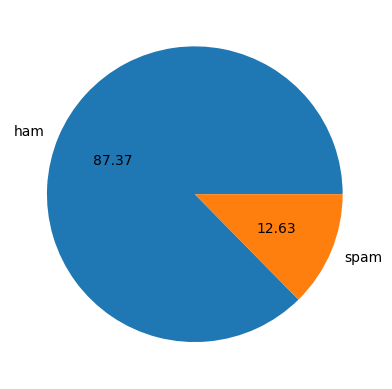

In [23]:
plt.pie(df['target'].value_counts(),labels= ['ham','spam'],autopct='%0.2f')
plt.show()

In [24]:
# hence data is imbalance

In [25]:
import nltk

In [26]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
df['num_characters'] = df['text'].apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [28]:
# number of words 
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [29]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [30]:
df.describe(include='all')

,target,text,num_characters,num_words,num_sentences
count,5169.000000,5169,5169.000000,5169.000000,5169.000000
unique,NaN,5169,NaN,NaN,NaN
top,NaN,Rofl. Its true to its name,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN
mean,0.126330,NaN,78.977945,18.455794,1.965564
std,0.332253,NaN,58.236293,13.324758,1.448541
min,0.000000,NaN,2.000000,1.000000,1.000000
25%,0.000000,NaN,36.000000,9.000000,1.000000
50%,0.000000,NaN,60.000000,15.000000,1.000000
75%,0.000000,NaN,117.000000,26.000000,2.000000


In [31]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='object')

In [32]:
# ham messages
df[df['target'] == 0].describe()

,target,num_characters,num_words,num_sentences
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [33]:
# spam messages
df[df['target'] == 1].describe()

,target,num_characters,num_words,num_sentences
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


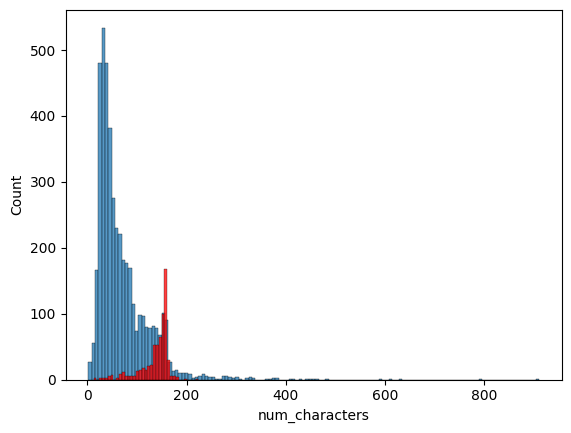

In [34]:
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')
plt.show()

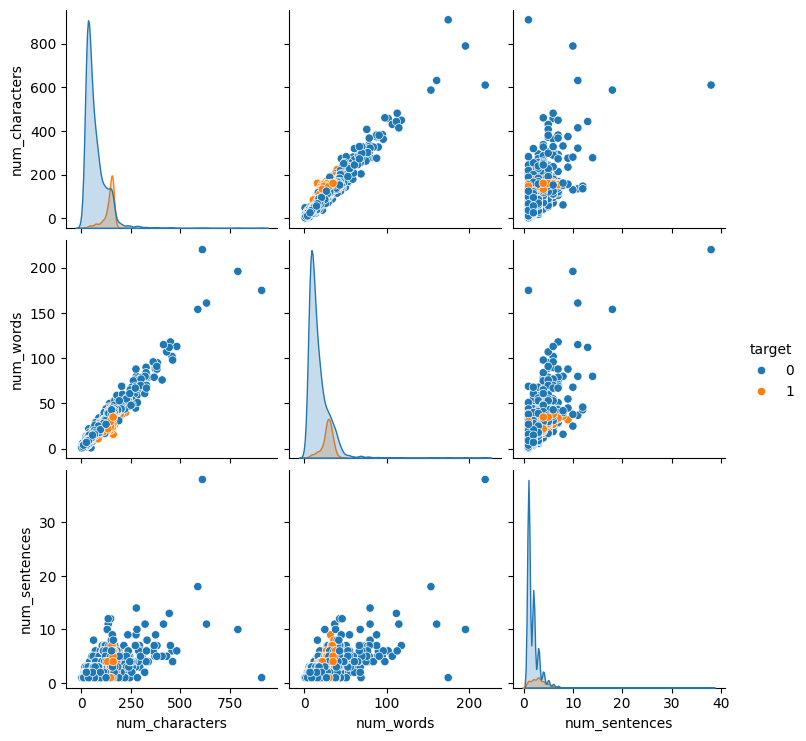

In [35]:
sns.pairplot(df,hue='target')
plt.show()

In [36]:
df.drop(columns=['text']).corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


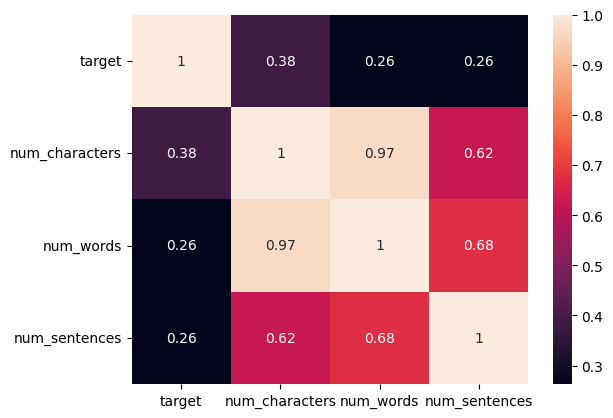

In [37]:
sns.heatmap(df.drop(columns=['text']).corr(),annot = True)
plt.show()

In [38]:
# Data Preprocessing
# 1. lower case
# 2. tokenization
# 3. remove stop words and punctuation
# 4. stemming

In [39]:
from nltk.corpus import stopwords 
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [40]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [41]:
from nltk.stem.porter import PorterStemmer 
ps = PorterStemmer()
ps.stem('loving')

'love'

In [42]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y.copy() 
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y.copy()
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    return ' '.join(y)

In [43]:
transform_text('Did you like my presentation on ML')

'like present ml'

In [44]:
print(f"First text befor text preprocessing:\n{df['text'][0]}\n")
print(f"First text after text preprocessing:\n{transform_text(df['text'][0])}")


First text befor text preprocessing:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

First text after text preprocessing:
go jurong point crazi avail bugi n great world la e buffet cine got amor wat


In [45]:
df['transformed_text'] = df['text'].apply(transform_text)

In [46]:

df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [47]:
from wordcloud import WordCloud 
wc = WordCloud(width=500,height=500,min_font_size=10,background_color = 'white')

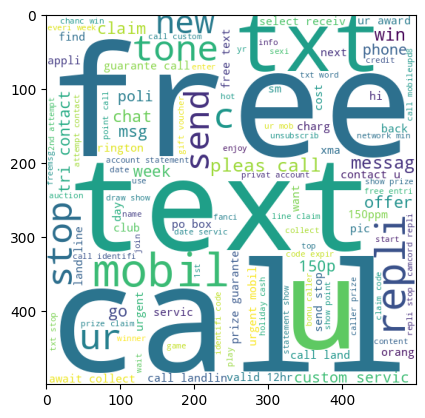

In [48]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

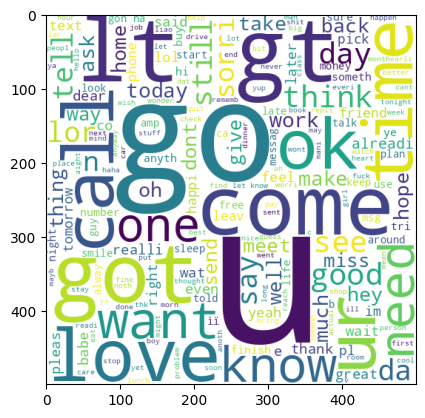

In [49]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [50]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [51]:
len(spam_corpus)

9939

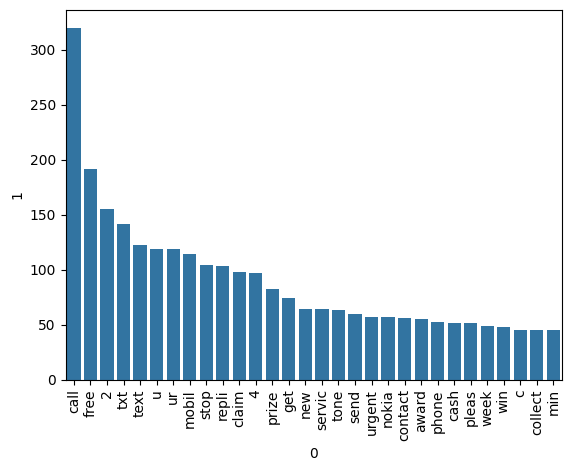

In [52]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [53]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [54]:
len(ham_corpus)

35404

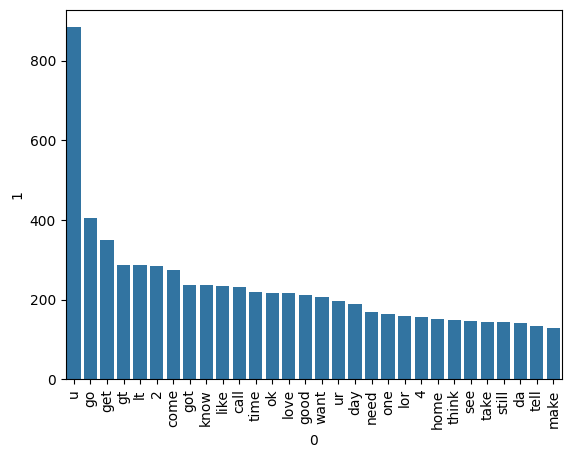

In [55]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

# Model building

In [56]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features = 3000)

In [57]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [58]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [59]:
X.shape

(5169, 3000)

In [60]:
y = df['target'].values

In [61]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train ,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [64]:
from sklearn.naive_bayes import GaussianNB ,MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score , confusion_matrix, precision_score

In [65]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [66]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8762088974854932
[[784 112]
 [ 16 122]]
0.5213675213675214


In [67]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9787234042553191
[[889   7]
 [ 15 123]]
0.9461538461538461


In [68]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [69]:
# we chose tfidfvectorizer and MNB model

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import BaggingClassifier 
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier 
from xgboost import XGBClassifier

In [71]:
svc = SVC(kernel='sigmoid',gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear',penalty ='l1')
rfc = RandomForestClassifier(n_estimators = 50, random_state=2)
abc = AdaBoostClassifier(n_estimators = 50, random_state=2)
bc  = BaggingClassifier(n_estimators = 50, random_state=2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state=2)
gbc = GradientBoostingClassifier(n_estimators = 50, random_state=2)
xgb = GradientBoostingClassifier(n_estimators = 50, random_state=2)

In [72]:
clfs = {
    'SVC': svc,
    'KNN': knc,
    'MNB': mnb,
    'DTC': dtc,
    'LRC': lrc,
    'RFC': rfc,
    'ABC': abc,
    'BC' : bc,
    'ETC': etc,
    'GBC': gbc,
    'XGB': xgb
}

In [73]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy , precision

In [74]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9700193423597679, 0.9421487603305785)

In [75]:
ac = []
ps = []

for name,clf in clfs.items():
    current_accuracy,current_precision =  train_classifier(clf,X_train,y_train,X_test,y_test)
    print('for',name)
    print('Accuracy : ',current_accuracy)
    print('Precision: ',current_precision,'\n')

    ac.append(current_accuracy)
    ps.append(current_precision)

for SVC
Accuracy :  0.9700193423597679
Precision:  0.9421487603305785 

for KNN
Accuracy :  0.9052224371373307
Precision:  0.9761904761904762 

for MNB
Accuracy :  0.9787234042553191
Precision:  0.9461538461538461 

for DTC
Accuracy :  0.9323017408123792
Precision:  0.8333333333333334 

for LRC
Accuracy :  0.9671179883945842
Precision:  0.9642857142857143 

for RFC
Accuracy :  0.9738878143133463
Precision:  0.9826086956521739 

for ABC
Accuracy :  0.9216634429400387
Precision:  0.8202247191011236 

for BC
Accuracy :  0.9584139264990329
Precision:  0.8682170542635659 

for ETC
Accuracy :  0.9748549323017408
Precision:  0.9745762711864406 

for GBC
Accuracy :  0.9506769825918762
Precision:  0.9306930693069307 

for XGB
Accuracy :  0.9506769825918762
Precision:  0.9306930693069307 



In [76]:
pd.DataFrame({'Algos':clfs.keys(),'Accuracy': ac,'Precision':ps}).sort_values('Precision',ascending=False)

,Algos,Accuracy,Precision
5,RFC,0.973888,0.982609
1,KNN,0.905222,0.976190
8,ETC,0.974855,0.974576
4,LRC,0.967118,0.964286
2,MNB,0.978723,0.946154
0,SVC,0.970019,0.942149
9,GBC,0.950677,0.930693
10,XGB,0.950677,0.930693
7,BC,0.958414,0.868217
3,DTC,0.932302,0.833333


In [77]:
# model improve
# 1. Change the max features parameters of Tfidf

In [78]:
import pickle 
# pickle.dump(tfidf,open('vectorizer.pkl'.'wb'))
# pickle.dump(mnb,open('model.pkl','wb'))

In [79]:
# Save the TF-IDF vectorizer
with open('/kaggle/working/vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save the trained model
with open('/kaggle/working/model.pkl', 'wb') as f:
    pickle.dump(mnb, f)

print("Files saved successfully!")

# Verify that the files exist
print(os.listdir('/kaggle/working'))

Files saved successfully!
['vectorizer.pkl', '__notebook__.ipynb', 'model.pkl']
